In [63]:
import json
import numpy as np
import math
from statistics import NormalDist
from typing import Any
import pandas as pd
import matplotlib.pyplot as plt

## 1. Price Data Loading

Load 3 days of exchange price data (days -1, 0, 1) for both products. Filter out rows where `mid_price <= 0` (corrupt ticks). Print per-product std to confirm:
- `ASH_COATED_OSMIUM` — low std (~5), essentially stationary → pure market-making product
- `INTARIAN_PEPPER_ROOT` — high std (~288), but this is mostly the linear trend, not noise → trending product

In [64]:
# read csv
dfs = {}
for day in [-1, 0, 1]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/prices_round_2_day_{day}.csv',
        sep=';'
    )
    dfs[day] = df[df['mid_price'] > 0]  # filter out rows with mid_price <= 0
    print(dfs[day].groupby('product')['mid_price'].std())

product
ASH_COATED_OSMIUM         4.466929
INTARIAN_PEPPER_ROOT    288.653472
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         5.659611
INTARIAN_PEPPER_ROOT    288.609638
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         5.018676
INTARIAN_PEPPER_ROOT    288.746423
Name: mid_price, dtype: float64


## 2. Mid Price Over Time

Overlay mid price vs timestamp across all 3 days for each product. Each day is a separate line so we can see:
- Pepper root trending upward ~1000 per day (day -1 ≈ 11000, day 0 ≈ 12000, day 1 ≈ 13000)
- Osmium staying flat around 10000 with small noise — confirms it's a pure market-making product

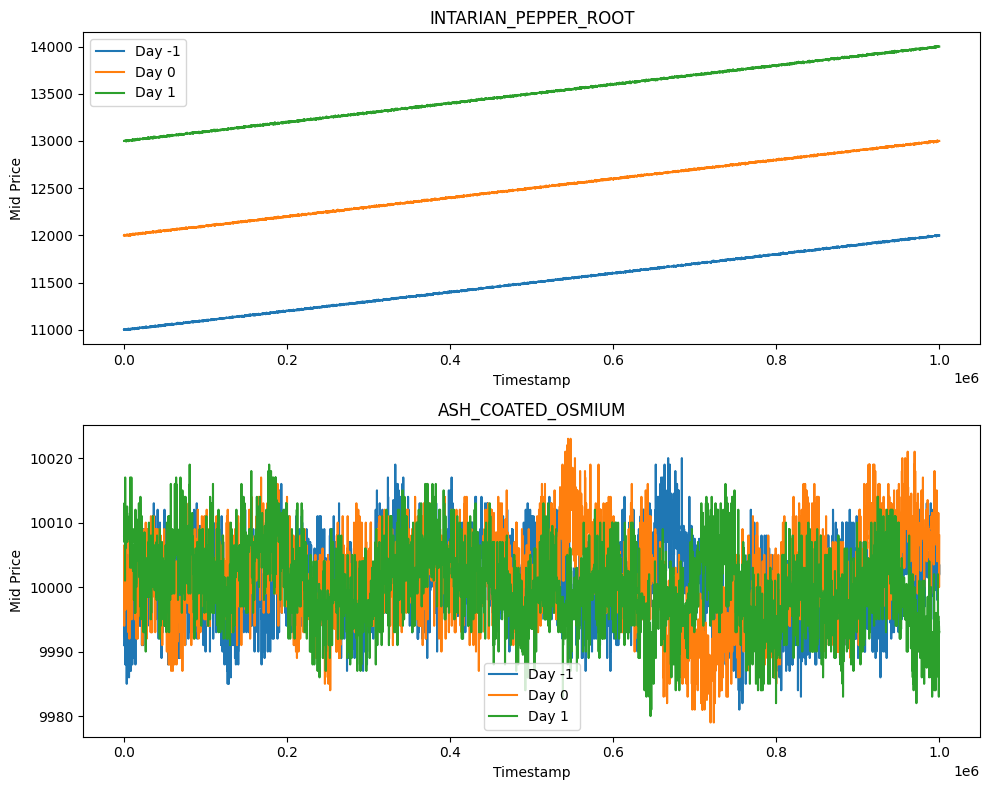

In [65]:
# plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

products = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']

for ax, product in zip(axes, products):
    for day, df in dfs.items():
        product_df = df[df['product'] == product]
        ax.plot(product_df['timestamp'], product_df['mid_price'], label=f'Day {day}')
    ax.set_title(product)
    ax.legend()
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()


## 3. Detrending INTARIAN_PEPPER_ROOT

Fit a linear regression (price ~ timestamp) per day to extract the slope and per-day intercept. Key things to verify:
- Slope ≈ 0.001 on all days — confirms the hardcoded `SLOPE` in the trader is still correct for round 2
- Intercepts jump by ~1000 each day (10999 → 12000 → 12999) — we must reset the intercept each day
- Residual std ≈ 2 ticks — this is the actual noise around the trend, meaning ±2 is a tight fair value estimate

In [66]:
# detrending the price series for intarian pepper root
for day, df in dfs.items():
    product_df = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
    
    coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
    product_df['trend'] = np.polyval(coeffs, product_df['timestamp'])
    product_df['residual'] = product_df['mid_price'] - product_df['trend']
    
    print(f"Day {day}: slope={coeffs[0]:.6f}, intercept={coeffs[1]:.2f}, residual std={product_df['residual'].std():.4f}")

Day -1: slope=0.001000, intercept=10999.98, residual std=2.1946
Day 0: slope=0.001000, intercept=12000.01, residual std=2.3642
Day 1: slope=0.001000, intercept=12999.92, residual std=2.5428


## 4. Combined Slope Estimate

Fit across all 3 days concatenated as a sanity check. The combined intercept is meaningless (timestamp restarts each day so the mid-day intercept averages out), but the slope should still be ~0.001, confirming the trend is uniform across the whole round.

In [67]:
# Combine all days
all_days = pd.concat(dfs.values())
product_df = all_days[all_days['product'] == 'INTARIAN_PEPPER_ROOT']
coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
print(f"Combined slope: {coeffs[0]:.6f}, intercept: {coeffs[1]:.2f}")


Combined slope: 0.001000, intercept: 11999.94


## 5. Trade Data — Bot Identification (Day -1)

Load market trades for day -1. Each row is an exchange-matched trade (not necessarily involving us). `buyer`/`seller` are always NaN since the platform anonymises counterparties.

Goal: **fingerprint bots by their behaviour** — bots tend to trade at consistent lot sizes, at predictable price offsets from mid, or at regular time intervals. Identifying these patterns lets us predict when and where they'll trade and position ourselves to capture their flow.

In [68]:
trades = pd.read_csv("/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/trades_round_2_day_-1.csv", sep=";")

# See what columns exist
print(trades.columns.tolist())
print(trades.head(10))

['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity']
   timestamp  buyer  seller                symbol currency    price  quantity
0          0    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9982.0         6
1       3600    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10001.0         3
2       4200    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10002.0         2
3       4400    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS  11010.0         5
4       5000    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS  10996.0         5
5       9100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9994.0         4
6       9600    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9989.0         6
7      10000    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9988.0         8
8      12100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9989.0         5
9      15100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10011.0         2


## 6. Fixed-Lot & Price-Extreme Fingerprinting

Two checks for bot signatures:
1. **Fixed lot sizes** — print quantity frequency; a bot that always trades e.g. 6 lots will dominate the distribution
2. **Trades at daily extremes** — check whether any trades hit the day's min or max price, and what quantity; a mean-reversion bot buys at the low and sells at the high with a predictable size

In [69]:
pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

# Find trades with suspicious fixed lot sizes
print(trades['quantity'].value_counts())

# Look for trades that happen at daily extremes
pepper['daily_min'] = pepper.groupby(pepper['timestamp'] // 1000000)['price'].transform('min')
pepper['daily_max'] = pepper.groupby(pepper['timestamp'] // 1000000)['price'].transform('max')

# Trades at daily extremes
at_low = pepper[pepper['price'] == pepper['daily_min']]
at_high = pepper[pepper['price'] == pepper['daily_max']]

print(at_low['quantity'].value_counts())
print(at_high['quantity'].value_counts())

quantity
5     144
6     142
3     132
4     127
7      86
2      67
8      46
10     23
9      23
Name: count, dtype: int64
quantity
5    1
Name: count, dtype: int64
quantity
7    1
Name: count, dtype: int64


## 7. Trade Quantity vs Time — Scatter

Scatter quantity over time for each product. Looking for:
- A specific lot size appearing at regular timestamps → scheduled bot
- Clustering of quantity at particular time windows → reactive bot triggered by price events
- Also print (quantity, price) frequency table to find if a bot trades a fixed lot at a fixed price repeatedly

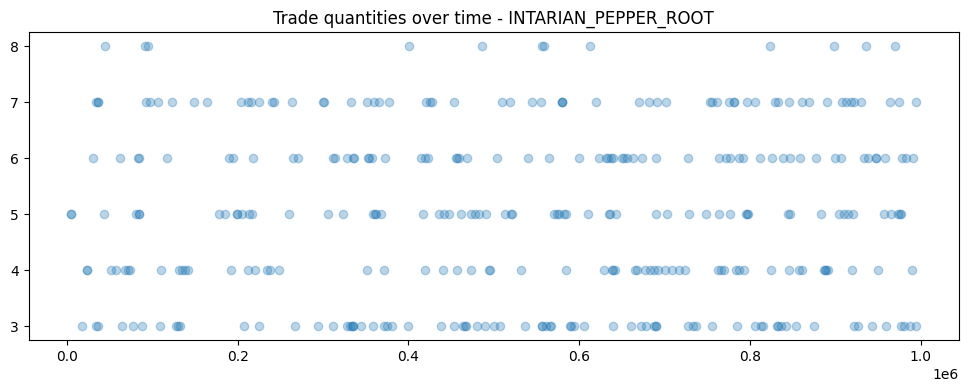

quantity  price  
5         11576.0    2
7         11586.0    2
          11800.0    2
5         11361.0    2
6         11451.0    2
          11770.0    2
4         11769.0    2
5         11637.0    2
3         11599.0    2
4         11675.0    2
6         11360.0    1
          11368.0    1
          11410.0    1
          11594.0    1
          11417.0    1
          11421.0    1
          11450.0    1
          11359.0    1
          11351.0    1
          11463.0    1
dtype: int64


In [70]:
pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT']

# Plot quantity over time to spot patterns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.scatter(pepper['timestamp'], pepper['quantity'], alpha=0.3)
plt.title('Trade quantities over time - INTARIAN_PEPPER_ROOT')
plt.show()

# Also check if any quantities repeat suspiciously often at specific prices
print(pepper.groupby(['quantity', 'price']).size().sort_values(ascending=False).head(20))

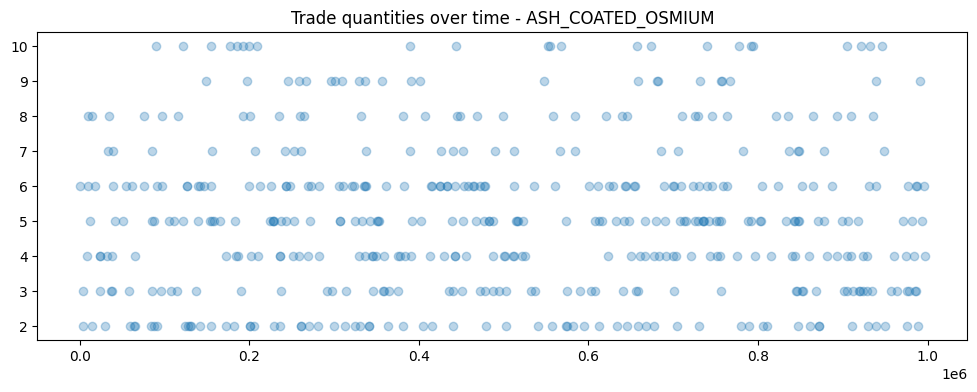

quantity
5     82
6     79
4     68
2     67
3     58
8     34
7     25
10    23
9     23
Name: count, dtype: int64


In [71]:
osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM']

plt.figure(figsize=(12,4))
plt.scatter(osmium['timestamp'], osmium['quantity'], alpha=0.3)
plt.title('Trade quantities over time - ASH_COATED_OSMIUM')
plt.show()

print(osmium['quantity'].value_counts())

## 8. Price/Time Overlay — Mid Price + Trade Dots (Day -1)

Plot mid price (blue line) with each trade price as a red dot, for both products. This is the primary bot-detection chart:
- **Horizontal bands of red dots** at a fixed offset from the blue line = bot quoting at a fixed spread from mid
- Red dots that track the blue line closely = market-maker being taken out by an aggressive bot
- Isolated dots far from mid = potential informed flow or a one-off rogue order

Note: uses `dfs[-1]` (round 2 day -1 prices) and `trades` (round 2 day -1) — both from the same day and round.

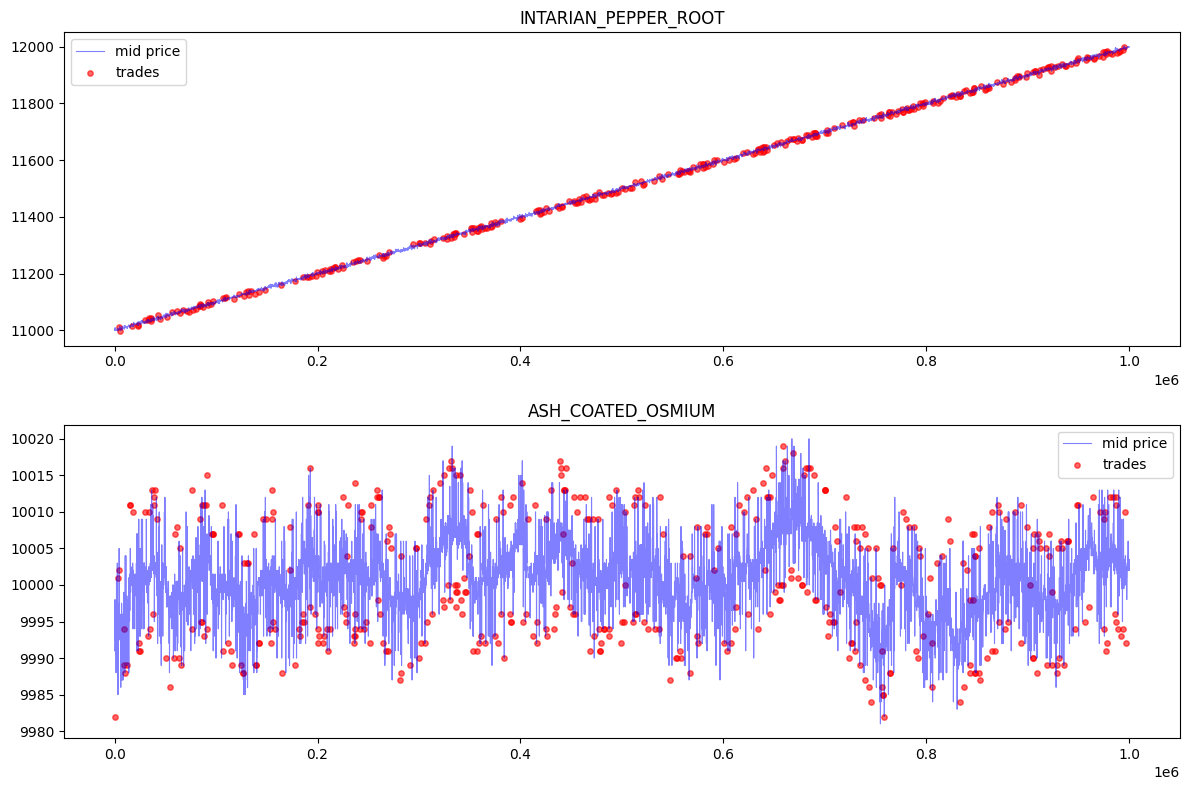

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, product in zip(axes, ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    # Use only day -1
    product_prices = dfs[-1][dfs[-1]['product'] == product]
    product_trades = trades[trades['symbol'] == product]
    
    ax.plot(product_prices['timestamp'], product_prices['mid_price'], 
            alpha=0.5, color='blue', label='mid price', linewidth=0.8)
    ax.scatter(product_trades['timestamp'], product_trades['price'], 
               alpha=0.6, color='red', s=15, label='trades')
    ax.set_title(product)
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Deviation from Mid — ASH_COATED_OSMIUM (Day -1)

Merge trade prices with mid prices at matching timestamps, then compute `deviation = trade_price - mid_price`. For osmium (stationary product), a bot market-maker will post at fixed offsets — e.g. always quoting ±8 from mid. A spike at ±8 in the value counts is the bot's spread fingerprint, and tells us how tight we need to quote to beat it.

In [73]:
osmium_prices = dfs[-1][dfs[-1]['product'] == 'ASH_COATED_OSMIUM'][['timestamp', 'mid_price']]
osmium_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].copy()

# merge to get mid price at trade time
merged = osmium_trades.merge(osmium_prices, on='timestamp', how='left')

# how far is the trade price from mid?
merged['deviation'] = merged['price'] - merged['mid_price']
print(merged['deviation'].describe())
print(merged['deviation'].value_counts().head(10))

count    459.000000
mean      -0.342048
std        8.128646
min      -10.500000
25%       -8.000000
50%        0.000000
75%        8.000000
max       10.500000
Name: deviation, dtype: float64
deviation
-8.0     144
 8.0     129
-9.0      36
-9.5      32
 9.0      32
 9.5      28
 0.0      15
 10.5      5
-10.5      5
 5.5       4
Name: count, dtype: int64


## 10. Deviation from Mid — INTARIAN_PEPPER_ROOT (Day -1)

Same deviation analysis for the trending product. Here deviation is relative to the raw mid price (not the detrended fair value), so a bot quoting at a fixed spread from mid will show the same clustering. We can use the dominant deviation values to calibrate how aggressively we need to post to get top-of-book priority over the bots.

In [74]:
pepper_prices = dfs[-1][dfs[-1]['product'] == 'INTARIAN_PEPPER_ROOT'][['timestamp', 'mid_price']]
pepper_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

merged_pepper = pepper_trades.merge(pepper_prices, on='timestamp', how='left')
merged_pepper['deviation'] = merged_pepper['price'] - merged_pepper['mid_price']

print(merged_pepper['deviation'].describe())
print(merged_pepper['deviation'].value_counts().head(10))

count    331.000000
mean       0.202417
std        5.703783
min       -8.000000
25%       -6.000000
50%        1.000000
75%        6.500000
max        8.500000
Name: deviation, dtype: float64
deviation
 6.5    50
-6.5    41
 6.0    36
-6.0    29
 1.0    26
-1.5    23
 7.5    22
-7.5    21
-8.0    16
 1.5    14
Name: count, dtype: int64


## 11. All-Days Deviation Analysis (Days -1, 0, 1)

Reload all 3 days of round 2 trades and merge with prices on both `day` and `timestamp` (to avoid mixing prices across days). Filter deviations > 50 as data artefacts. The larger sample makes the bot fingerprint clearer — if the same deviation cluster (e.g. ±6.5 for pepper, ±8 for osmium) appears consistently across all days, it's a systematic bot behaviour we can exploit.

In [75]:
# Reload trades with day column
all_trades = pd.concat([
    pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/trades_round_2_day_{day}.csv',
        sep=';'
    ).assign(day=day)
    for day in [-1, 0, 1]
])

# Now merge on both day and timestamp
for product in ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']:
    product_trades = all_trades[all_trades['symbol'] == product].copy()
    
    all_prices = pd.concat([
        dfs[day][dfs[day]['product'] == product][['day', 'timestamp', 'mid_price']]
        for day in [-1, 0, 1]
    ])
    
    merged = product_trades.merge(all_prices, on=['day', 'timestamp'], how='left')
    merged['deviation'] = merged['price'] - merged['mid_price']
    merged = merged[merged['deviation'].abs() < 50]
    
    print(f"\n{product}:")
    print(merged['deviation'].describe())
    print(merged['deviation'].value_counts().head(10))


INTARIAN_PEPPER_ROOT:
count    996.000000
mean       0.053715
std        6.116776
min      -11.000000
25%       -6.500000
50%        0.000000
75%        6.500000
max       11.000000
Name: deviation, dtype: float64
deviation
 6.5    80
-6.5    79
 7.0    79
-1.5    71
-7.0    66
-7.5    64
 7.5    60
 1.5    55
 1.0    50
-2.0    48
Name: count, dtype: int64

ASH_COATED_OSMIUM:
count    1395.000000
mean       -0.222939
std         8.037625
min       -10.500000
25%        -8.000000
50%         0.000000
75%         8.000000
max        10.500000
Name: deviation, dtype: float64
deviation
-8.0     419
 8.0     413
-9.0     108
-9.5      96
 9.5      80
 9.0      79
 0.0      55
 10.5     17
-10.5     13
 3.0      12
Name: count, dtype: int64


In [76]:
print(all_trades.columns.tolist())
print(all_trades.head(3))

['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day']
   timestamp  buyer  seller             symbol currency    price  quantity  \
0          0    NaN     NaN  ASH_COATED_OSMIUM   XIRECS   9982.0         6   
1       3600    NaN     NaN  ASH_COATED_OSMIUM   XIRECS  10001.0         3   
2       4200    NaN     NaN  ASH_COATED_OSMIUM   XIRECS  10002.0         2   

   day  
0   -1  
1   -1  
2   -1  


In [77]:
# import numpy as np
# from scipy.optimize import minimize_scalar

# speed_pct = 50  # fix speed
# for r in range(0, 100 - speed_pct, 1):
#     s = 100 - speed_pct - r  # scale gets the rest
#     research = 200000 * np.log(1+r) / np.log(101)
#     scale = 7 * s / 100
#     budget = 50000  # always 50k if using all budget
#     gross = research * scale * 0.6  # assume 0.5 speed multiplier
#     print(f"R={r}%, Sc={s}%, Spd={speed_pct}%: PnL={gross - budget:.0f}")

In [78]:
# read csv
dfs = {}
for day in [0, 1, 2]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round3/prices_round_3_day_{day}.csv',
        sep=';'
    )
    dfs[day] = df[df['mid_price'] > 0]  # filter out rows with mid_price <= 0
    print(dfs[day].groupby('product')['mid_price'].std())

product
HYDROGEL_PACK          25.328358
VELVETFRUIT_EXTRACT    13.677795
VEV_4000               13.698111
VEV_4500               13.686640
VEV_5000               12.488839
VEV_5100               10.954784
VEV_5200                8.165664
VEV_5300                5.179954
VEV_5400                2.780724
VEV_5500                1.236892
VEV_6000                0.000000
VEV_6500                0.000000
Name: mid_price, dtype: float64
product
HYDROGEL_PACK          37.613011
VELVETFRUIT_EXTRACT    14.614362
VEV_4000               14.634019
VEV_4500               14.627799
VEV_5000               13.582436
VEV_5100               11.936931
VEV_5200                8.663725
VEV_5300                5.469853
VEV_5400                2.678290
VEV_5500                1.328696
VEV_6000                0.000000
VEV_6500                0.000000
Name: mid_price, dtype: float64
product
HYDROGEL_PACK          31.622161
VELVETFRUIT_EXTRACT    16.985339
VEV_4000               17.001434
VEV_4500             

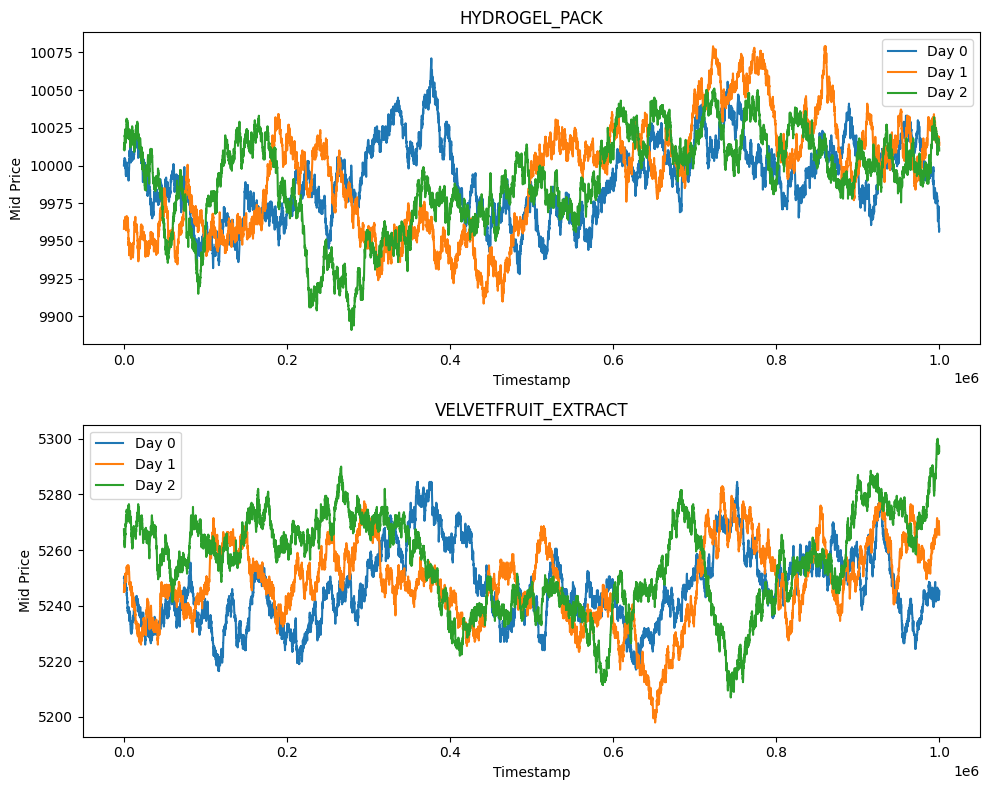

In [79]:
# plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for ax, product in zip(axes, products):
    for day, df in dfs.items():
        product_df = df[df['product'] == product]
        ax.plot(product_df['timestamp'], product_df['mid_price'], label=f'Day {day}')
    ax.set_title(product)
    ax.legend()
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()


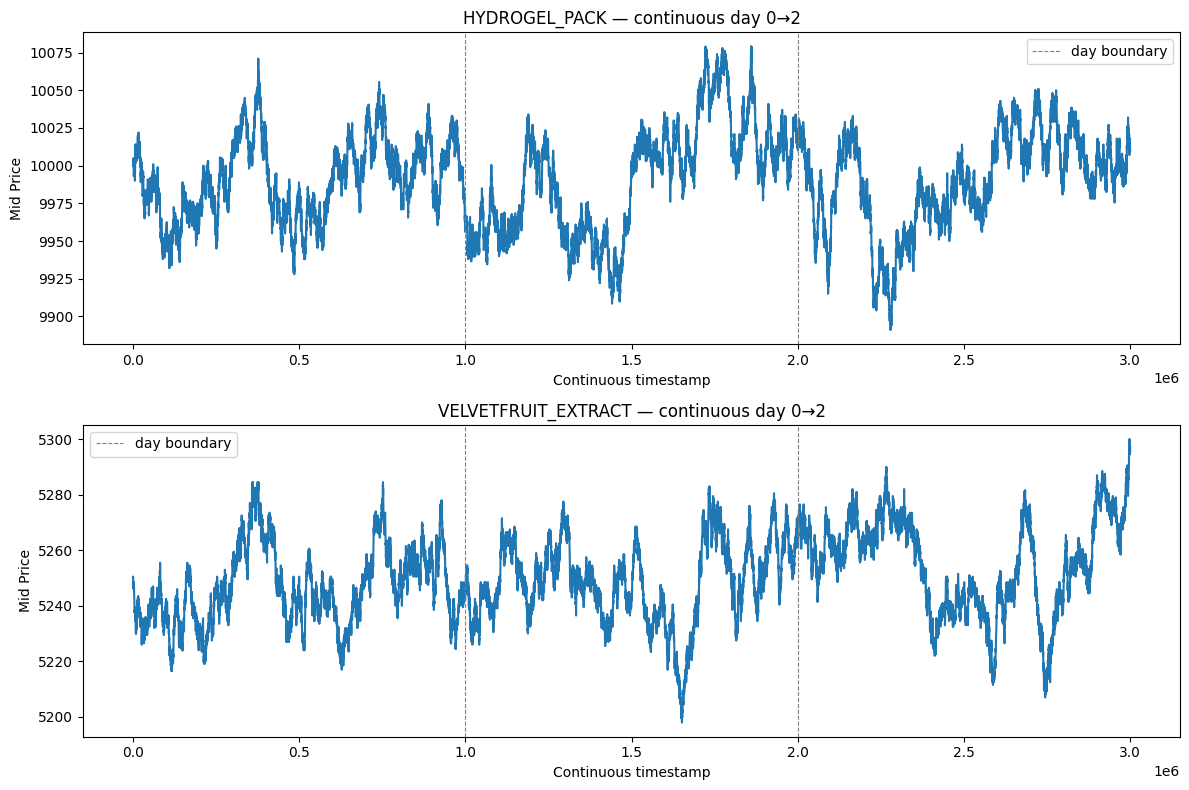

In [80]:
# Continuous plot: days 0-2 stitched together (offset timestamp by 1_000_000 per day)
DAY_LENGTH = 1_000_000

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for ax, product in zip(axes, products):
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == product].copy()
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'])
    ax.set_title(f'{product} — continuous day 0→2')
    ax.set_xlabel('Continuous timestamp')
    ax.set_ylabel('Mid Price')
    ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8, label='day boundary')
    ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()


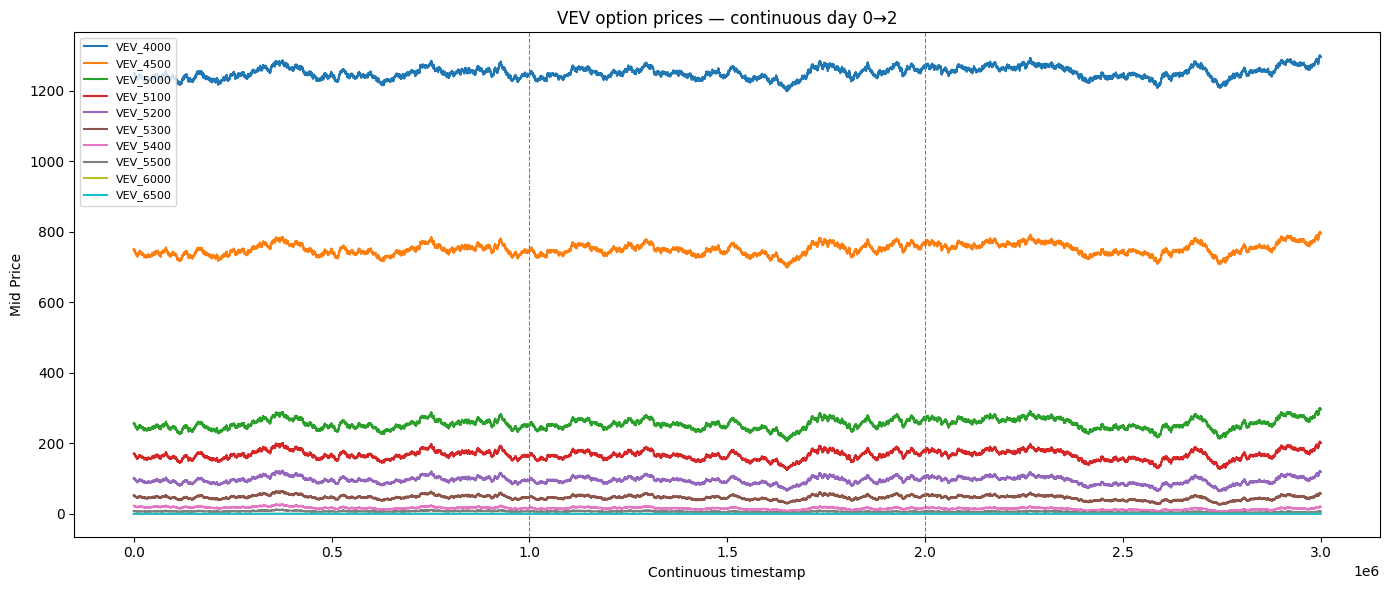

In [81]:
# Continuous option prices (VEV_*) across days 0-2
DAY_LENGTH = 1_000_000

options = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
           'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
           'VEV_6000', 'VEV_6500']

fig, ax = plt.subplots(figsize=(14, 6))

for opt in options:
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == opt].copy()
        if chunk.empty:
            continue
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    if not frames:
        continue
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'], label=opt)

ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('VEV option prices — continuous day 0→2')
ax.set_xlabel('Continuous timestamp')
ax.set_ylabel('Mid Price')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


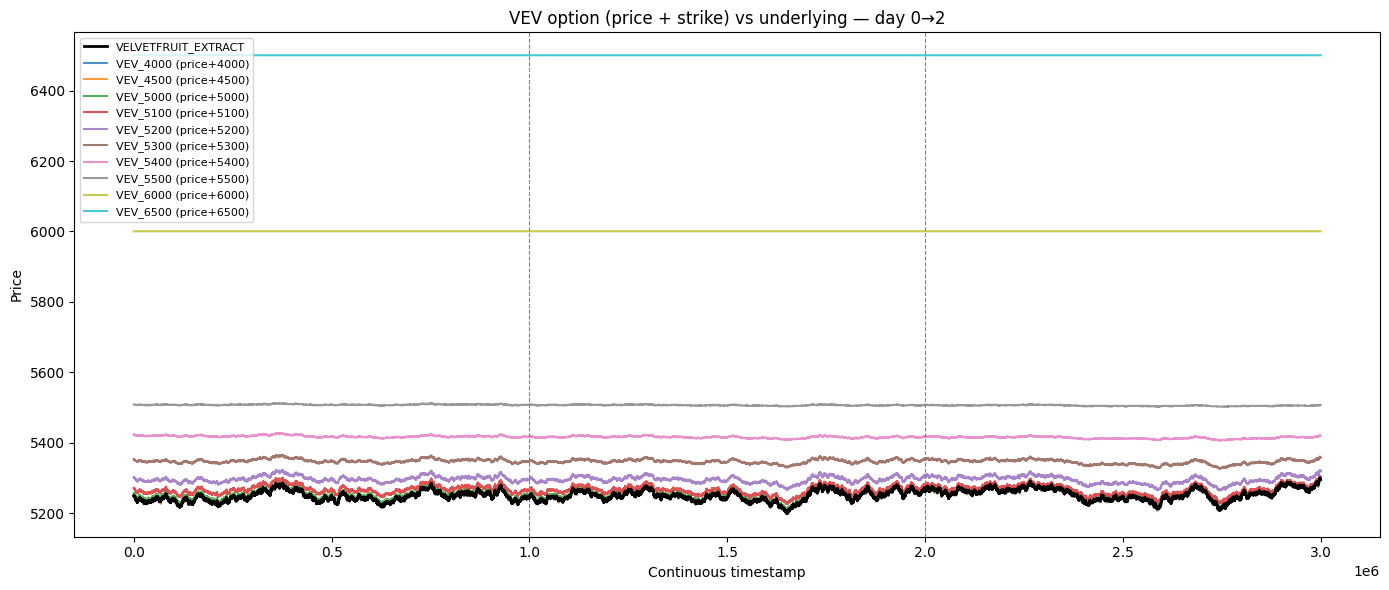

In [82]:
# VEV options (price + strike) vs VELVETFRUIT_EXTRACT — same y-axis
DAY_LENGTH = 1_000_000

options = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
           'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
           'VEV_6000', 'VEV_6500']

fig, ax = plt.subplots(figsize=(14, 6))

# Underlying
frames = []
for day, df in dfs.items():
    chunk = df[df['product'] == 'VELVETFRUIT_EXTRACT'].copy()
    chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
    frames.append(chunk)
underlying = pd.concat(frames).sort_values('cont_ts')
ax.plot(underlying['cont_ts'], underlying['mid_price'],
        color='black', linewidth=2, label='VELVETFRUIT_EXTRACT', zorder=5)

# Options: plot option_price + strike on same scale
cmap = plt.cm.tab10
for i, opt in enumerate(options):
    strike = int(opt.split('_')[1])
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == opt].copy()
        if chunk.empty:
            continue
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    if not frames:
        continue
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'] + strike,
            color=cmap(i / len(options)), alpha=0.8, label=f'{opt} (price+{strike})')

ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Continuous timestamp')
ax.set_ylabel('Price')
ax.set_title('VEV option (price + strike) vs underlying — day 0→2')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


# Round 4 Counterparty (Mark XX) Analysis

Round 4 unlocks the `buyer` / `seller` columns with named `Mark XX` counterparties. This section answers: are any of them stable winners or losers, and can we plausibly trade alongside them given spread structure and "closed pair" effects.

Earlier finding: a naive "follow Mark 14 / fade Mark 38" strategy on HYDROGEL_PACK lost ~800k locally because Mark 14 buys at the bid; the next-tick best-ask is ~16 above his entry, so chasing him is structurally bad.

In [83]:
# ── R4 setup ────────────────────────────────────────────────────────────────
import os, csv
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

R4_DIR = "/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round4"
DAYS = [1, 2, 3]
COUNTERPARTIES = [f"Mark {n:02d}" for n in (1, 14, 22, 38, 49, 55, 67)]
UNDERLYINGS = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VOUCHERS = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500",
]
ALL_SYMBOLS = UNDERLYINGS + VOUCHERS
print("Counterparties:", COUNTERPARTIES)

Counterparties: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']


In [84]:
# ── Load R4 trades + prices ─────────────────────────────────────────────────
def load_r4_trades():
    out = []
    for d in DAYS:
        with open(os.path.join(R4_DIR, f"trades_round_4_day_{d}.csv")) as fh:
            for row in csv.DictReader(fh, delimiter=";"):
                out.append({
                    "day": d, "timestamp": int(row["timestamp"]),
                    "buyer": row["buyer"], "seller": row["seller"],
                    "symbol": row["symbol"], "price": float(row["price"]),
                    "quantity": int(row["quantity"]),
                })
    return out

def load_r4_prices():
    by_key = defaultdict(list)
    for d in DAYS:
        with open(os.path.join(R4_DIR, f"prices_round_4_day_{d}.csv")) as fh:
            for row in csv.DictReader(fh, delimiter=";"):
                ts = int(row["timestamp"]); sym = row["product"]
                try: mid = float(row["mid_price"])
                except ValueError: continue
                try: bb = float(row["bid_price_1"])
                except ValueError: bb = float("nan")
                try: ba = float(row["ask_price_1"])
                except ValueError: ba = float("nan")
                by_key[(d, sym)].append((ts, mid, bb, ba))
    out = {d: {} for d in DAYS}
    for (d, sym), rows in by_key.items():
        rows.sort(key=lambda r: r[0])
        out[d][sym] = (
            np.array([r[0] for r in rows], dtype=np.int64),
            np.array([r[1] for r in rows], dtype=float),
            np.array([r[2] for r in rows], dtype=float),
            np.array([r[3] for r in rows], dtype=float),
        )
    return out

def lookup_at(ts_a, val_a, ts):
    if ts_a.size == 0: return float("nan")
    idx = np.searchsorted(ts_a, ts, side="right") - 1
    if idx < 0: return float("nan")
    return float(val_a[idx])

trades_r4 = load_r4_trades()
prices_r4 = load_r4_prices()
print(f"Loaded {len(trades_r4)} trades across {len(DAYS)} days")

Loaded 4281 trades across 3 days


## Part 1 — Per-counterparty PnL by product, by day

Realised cash + mark-to-market at each day's last mid. Print per (Mark, product, day) plus per-Mark daily totals, then label each Mark as consistent winner / loser / mixed.

In [85]:
# ── Part 1: per-Mark PnL ────────────────────────────────────────────────────
last_mid = {}
for d in DAYS:
    for sym, (ts_a, mid_a, _, _) in prices_r4[d].items():
        if mid_a.size: last_mid[(d, sym)] = float(mid_a[-1])

cash = defaultdict(float); pos = defaultdict(int)
for tr in trades_r4:
    d, b, s, sym, p, q = tr["day"], tr["buyer"], tr["seller"], tr["symbol"], tr["price"], tr["quantity"]
    if b in COUNTERPARTIES:
        cash[(d, b, sym)] -= p * q; pos[(d, b, sym)] += q
    if s in COUNTERPARTIES:
        cash[(d, s, sym)] += p * q; pos[(d, s, sym)] -= q

pnl = {}
for (d, m, sym), c in cash.items():
    mid = last_mid.get((d, sym), 0.0)
    pnl[(d, m, sym)] = c + pos[(d, m, sym)] * mid

# Per-Mark per-day totals + classification
daily = defaultdict(float)
for (d, m, sym), v in pnl.items():
    daily[(m, d)] += v
total = defaultdict(float)
for (m, d), v in daily.items():
    total[m] += v

print(f"{'Mark':<8} " + "  ".join(f"Day{d:>4}" for d in DAYS) + "    Total    Sign")
print("-" * 56)
winners, losers, mixed = [], [], []
for m in COUNTERPARTIES:
    signs = [1 if daily[(m, d)] > 0 else (-1 if daily[(m, d)] < 0 else 0) for d in DAYS]
    if all(s > 0 for s in signs): kind = "WIN  "; winners.append(m)
    elif all(s < 0 for s in signs): kind = "LOSE "; losers.append(m)
    else: kind = "MIXED"; mixed.append(m)
    row = "  ".join(f"{daily[(m, d)]:>7,.0f}" for d in DAYS)
    print(f"{m:<8} {row}   {total[m]:>8,.0f}   {kind}")
print(f"\nConsistent winners: {winners}\nConsistent losers : {losers}\nMixed             : {mixed}")

Mark     Day   1  Day   2  Day   3    Total    Sign
--------------------------------------------------------
Mark 01    4,516    5,924     -340     10,100   MIXED
Mark 14   23,016    5,654   13,536     42,206   WIN  
Mark 22   -6,972  -13,006    2,583    -17,395   MIXED
Mark 38  -18,308   -3,821  -11,492    -33,622   LOSE 
Mark 49   -4,700  -14,043    3,397    -15,346   MIXED
Mark 55   -6,590   -2,494   -4,119    -13,204   LOSE 
Mark 67    9,038   21,786   -3,564     27,261   MIXED

Consistent winners: ['Mark 14']
Consistent losers : ['Mark 38', 'Mark 55']
Mixed             : ['Mark 01', 'Mark 22', 'Mark 49', 'Mark 67']


AttributeError: 'numpy.float64' object has no attribute 'keys'

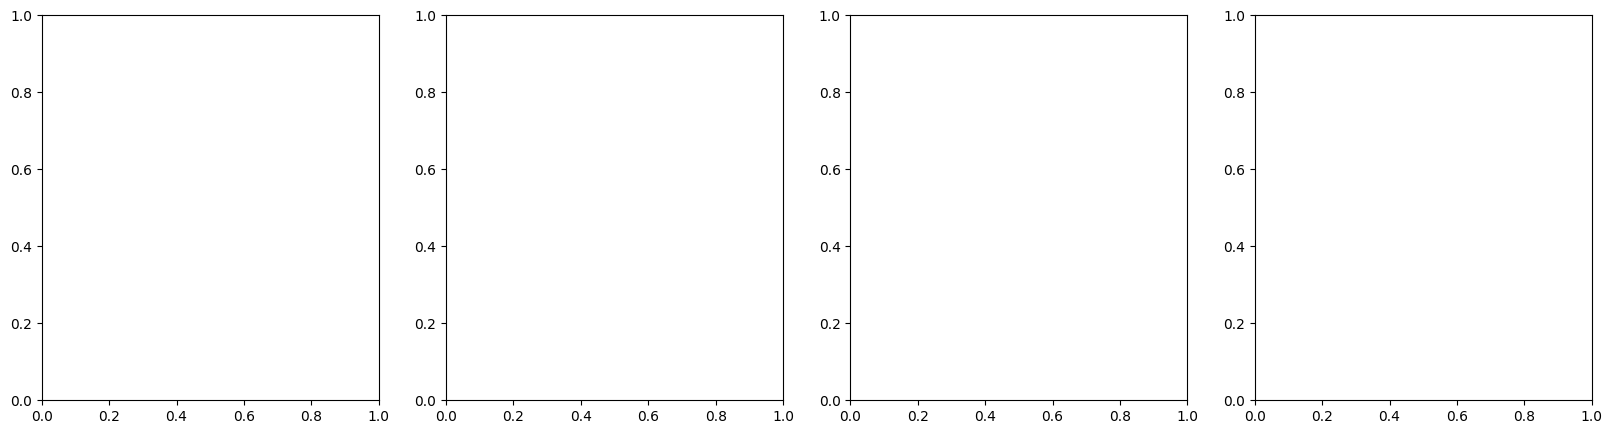

In [86]:
# ── Part 1: PnL chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(DAYS) + 1, figsize=(20, 5))
sym_for_plot = sorted({s for (_, _, s) in pnl.keys()})
cmap = plt.get_cmap("tab20")
for j, d in enumerate(DAYS):
    ax = axes[j]; x = np.arange(len(COUNTERPARTIES))
    bp = np.zeros(len(COUNTERPARTIES)); bn = np.zeros(len(COUNTERPARTIES))
    for k, sym in enumerate(sym_for_plot):
        vals = np.array([pnl.get((d, m, sym), 0.0) for m in COUNTERPARTIES])
        color = cmap(k % 20)
        pos_v = np.where(vals > 0, vals, 0); neg_v = np.where(vals < 0, vals, 0)
        ax.bar(x, pos_v, bottom=bp, color=color, label=sym if j == 0 else None)
        ax.bar(x, neg_v, bottom=bn, color=color)
        bp += pos_v; bn += neg_v
    ax.set_xticks(x); ax.set_xticklabels(COUNTERPARTIES, rotation=45, ha="right")
    ax.set_title(f"Day {d}"); ax.axhline(0, color="black", lw=0.5); ax.grid(axis="y", alpha=0.3)
ax = axes[-1]
totals = np.array([total[m] for m in COUNTERPARTIES])
ax.bar(np.arange(len(COUNTERPARTIES)), totals, color=["green" if v>0 else "red" for v in totals])
for xi, v in enumerate(totals):
    ax.text(xi, v, f"{v:,.0f}", ha="center", va="bottom" if v>0 else "top", fontsize=8)
ax.set_xticks(np.arange(len(COUNTERPARTIES))); ax.set_xticklabels(COUNTERPARTIES, rotation=45, ha="right")
ax.set_title("3-day total"); ax.axhline(0, color="black", lw=0.5); ax.grid(axis="y", alpha=0.3)
fig.legend(loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle("Part 1 — Counterparty PnL by product (stacked) and day", y=1.06)
fig.tight_layout()
fig.savefig("cp_pnl_by_product.png", bbox_inches="tight", dpi=110)
plt.show()

## Part 2 — Interaction matrices (who trades with whom)

For each product, count buyer↔seller pairs among the 7 Marks. Heatmap rows = buyer, cols = seller. Identify "closed pairs" — Marks that ONLY trade one specific counterparty on a given product (these can't be joined, since the only flow is bilateral).

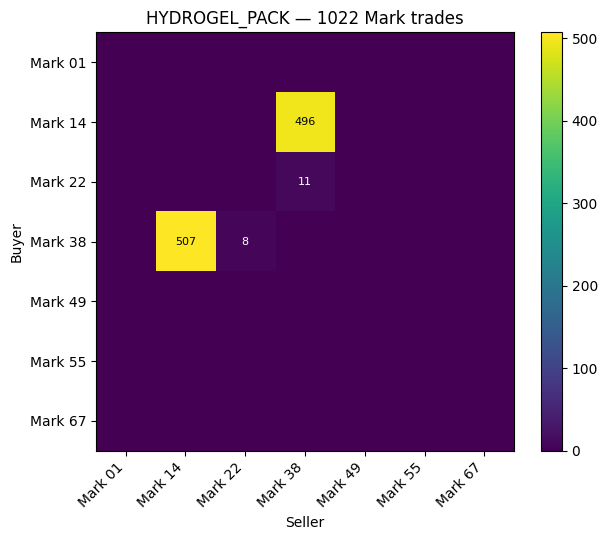

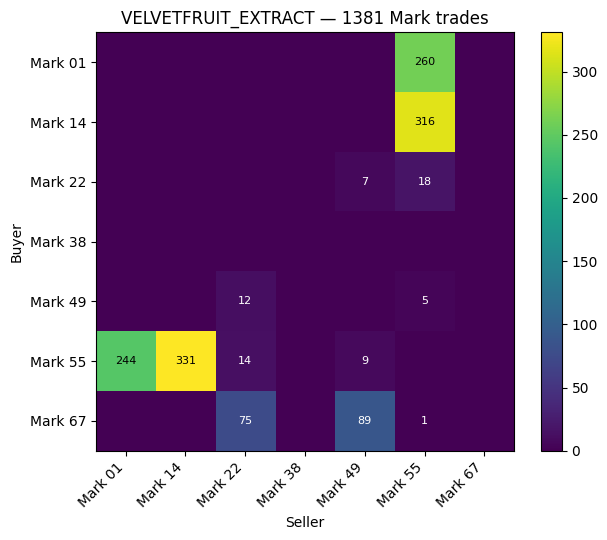

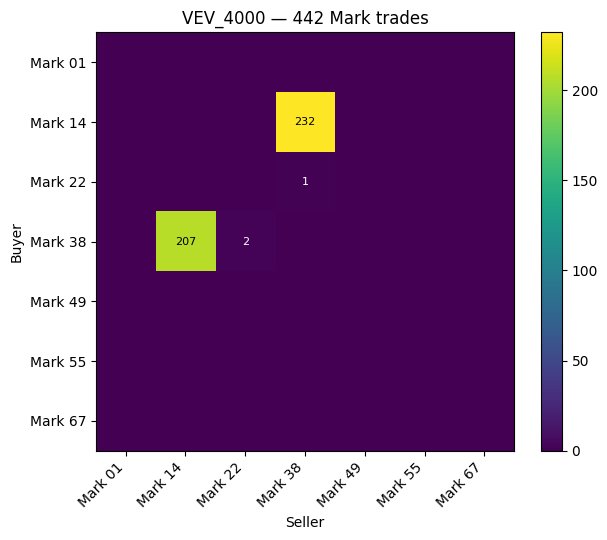

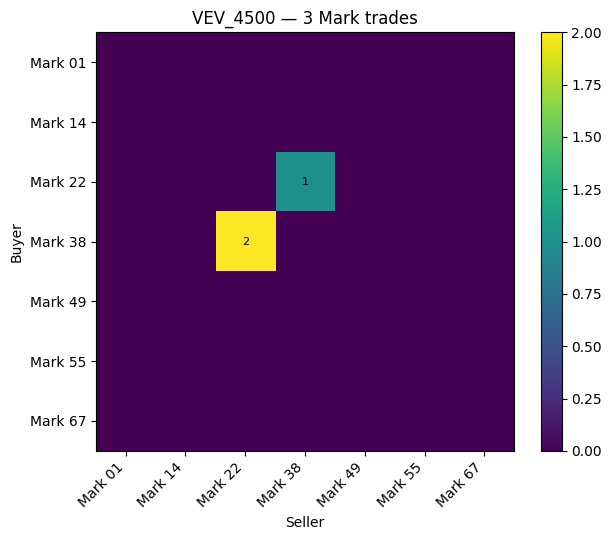

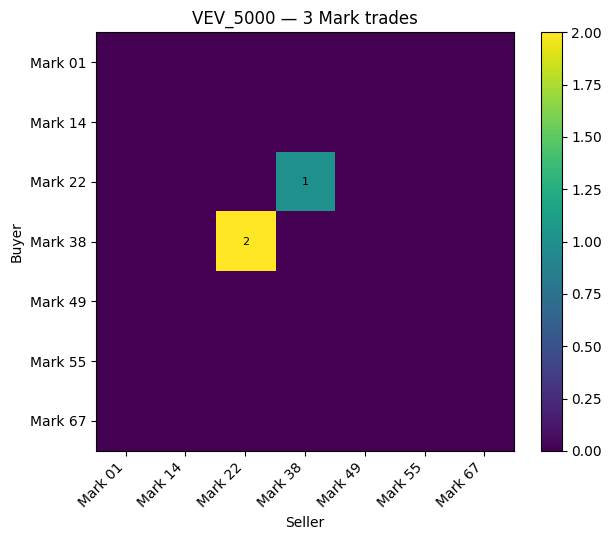

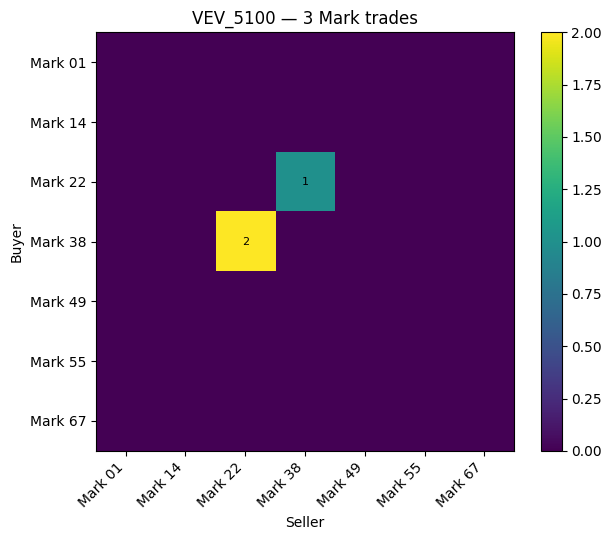

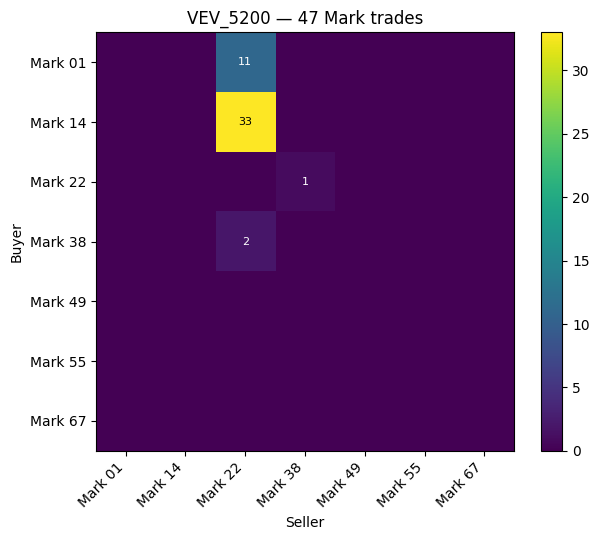

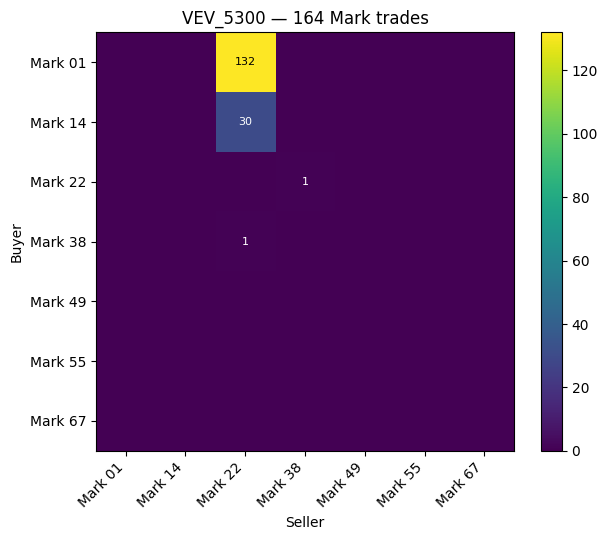

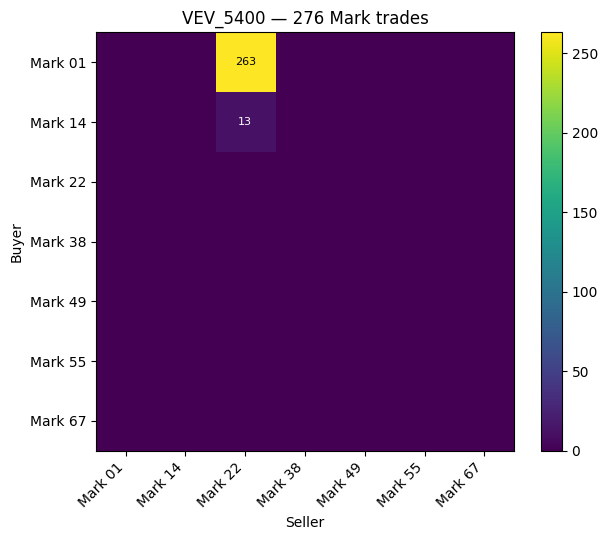

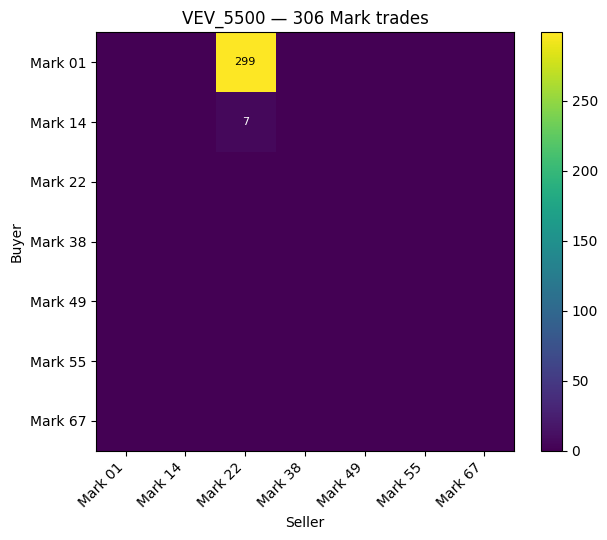

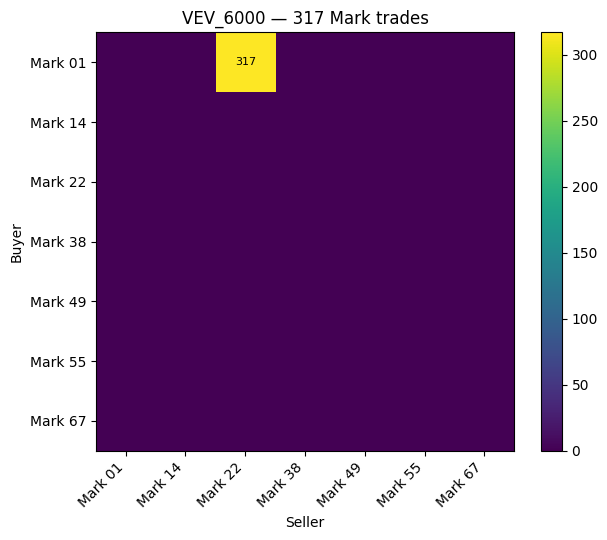

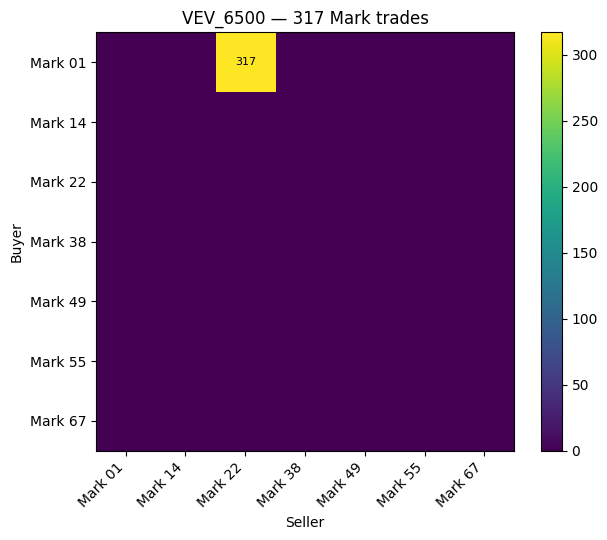

Top 3 partners per Mark per product:
  HYDROGEL_PACK:
    Mark 14: Mark 38(1003)
    Mark 22: Mark 38(19)
    Mark 38: Mark 14(1003), Mark 22(19)
  VELVETFRUIT_EXTRACT:
    Mark 01: Mark 55(504)
    Mark 14: Mark 55(647)
    Mark 22: Mark 67(75), Mark 55(32), Mark 49(19)
    Mark 49: Mark 67(89), Mark 22(19), Mark 55(14)
    Mark 55: Mark 14(647), Mark 01(504), Mark 22(32)
    Mark 67: Mark 49(89), Mark 22(75), Mark 55(1)
  VEV_4000:
    Mark 14: Mark 38(439)
    Mark 22: Mark 38(3)
    Mark 38: Mark 14(439), Mark 22(3)
  VEV_4500:
    Mark 22: Mark 38(3)
    Mark 38: Mark 22(3)
  VEV_5000:
    Mark 22: Mark 38(3)
    Mark 38: Mark 22(3)
  VEV_5100:
    Mark 22: Mark 38(3)
    Mark 38: Mark 22(3)
  VEV_5200:
    Mark 01: Mark 22(11)
    Mark 14: Mark 22(33)
    Mark 22: Mark 14(33), Mark 01(11), Mark 38(3)
    Mark 38: Mark 22(3)
  VEV_5300:
    Mark 01: Mark 22(132)
    Mark 14: Mark 22(30)
    Mark 22: Mark 01(132), Mark 14(30), Mark 38(2)
    Mark 38: Mark 22(2)
  VEV_5400:
    Mark

In [ ]:
# ── Part 2: interaction matrices ────────────────────────────────────────────
by_sym = defaultdict(list)
for tr in trades_r4:
    by_sym[tr["symbol"]].append(tr)

closed_pairs = []
top_partners = defaultdict(dict)

for sym in ALL_SYMBOLS:
    rows = by_sym.get(sym, [])
    if not rows: continue
    n = len(COUNTERPARTIES); mat = np.zeros((n, n), dtype=int)
    for tr in rows:
        if tr["buyer"] in COUNTERPARTIES and tr["seller"] in COUNTERPARTIES:
            mat[COUNTERPARTIES.index(tr["buyer"]), COUNTERPARTIES.index(tr["seller"])] += 1

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(mat, cmap="viridis")
    ax.set_xticks(range(n)); ax.set_xticklabels(COUNTERPARTIES, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(COUNTERPARTIES)
    ax.set_xlabel("Seller"); ax.set_ylabel("Buyer")
    ax.set_title(f"{sym} — {len(rows)} Mark trades")
    for i in range(n):
        for j in range(n):
            if mat[i, j]:
                ax.text(j, i, str(mat[i, j]), ha="center", va="center",
                        color="white" if mat[i, j] < mat.max()/2 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    fig.savefig(f"cp_matrix_{sym}.png", dpi=110)
    plt.show()

    # Top partners + closed-pair detection
    for i, m in enumerate(COUNTERPARTIES):
        partners = Counter()
        for j, other in enumerate(COUNTERPARTIES):
            partners[other] += int(mat[i, j])
            partners[other] += int(mat[j, i])
        partners = {k: v for k, v in partners.items() if v > 0}
        top_partners[sym][m] = sorted(partners.items(), key=lambda kv: -kv[1])[:3]
        if len(partners) == 1:
            closed_pairs.append((m, list(partners.keys())[0], sym, sum(partners.values())))

print("Top 3 partners per Mark per product:")
for sym, md in top_partners.items():
    print(f"  {sym}:")
    for m, top in md.items():
        if top:
            print(f"    {m}: " + ", ".join(f"{p}({n})" for p, n in top))

print("\nClosed pairs (Mark trades ONLY one counterparty on this product):")
for a, b, sym, n in closed_pairs:
    print(f"  {a} ↔ {b}  on {sym}  ({n} trades)")

## Part 3 — Aggressor vs maker

For each Mark trade, look up the prevailing mid at that exact timestamp. `price > mid` ⇒ buyer was aggressor (lifted offer); `price < mid` ⇒ seller was aggressor (hit bid); `price == mid` ⇒ split half-half. Tally per Mark.

Cross-reference: do winners (Mark 14) tend to be makers (collecting spread) or aggressors (predictive entries)?

Mark      Trades    %Agg    %Mak  AB  AS  MB  MS
------------------------------------------------------------
Mark 01     1843    0.0%  100.0%   0 0 1599 244
Mark 14     2172    0.0%  100.0%   1 0 1126 1045
Mark 22     1584   90.8%    9.2%   6 1432 36 110
Mark 38     1478  100.0%    0.0%   733 745 0 0
Mark 49      122    1.6%   98.4%   1 1 16 104
Mark 55     1198  100.0%    0.0%   598 600 0 0
Mark 67      165   99.4%    0.6%   164 0 1 0


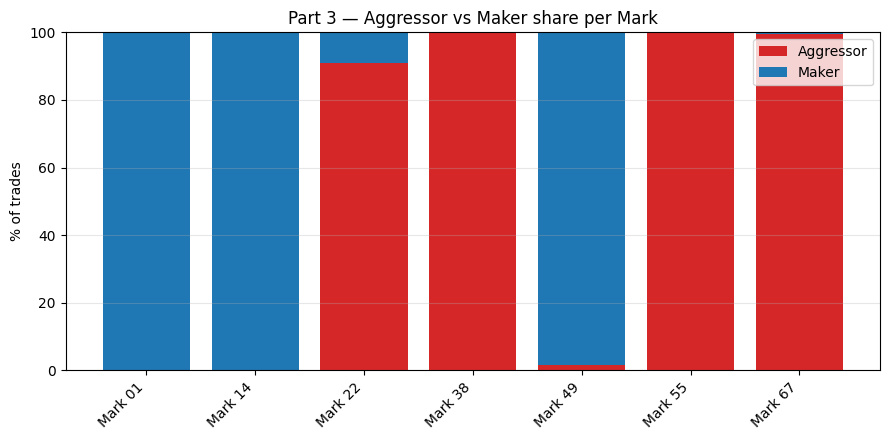

In [ ]:
# ── Part 3: aggressor vs maker ──────────────────────────────────────────────
tally = defaultdict(lambda: np.zeros(4, dtype=float))  # AB, AS, MB, MS
for tr in trades_r4:
    d, sym, ts, p = tr["day"], tr["symbol"], tr["timestamp"], tr["price"]
    arrs = prices_r4[d].get(sym)
    if arrs is None: continue
    ts_a, mid_a, _, _ = arrs
    mid = lookup_at(ts_a, mid_a, ts)
    if np.isnan(mid): continue
    for who, side in ((tr["buyer"], "buy"), (tr["seller"], "sell")):
        if who not in COUNTERPARTIES: continue
        if p > mid: idx = 0 if side == "buy" else 3
        elif p < mid: idx = 2 if side == "buy" else 1
        else:
            tally[who][0 if side == "buy" else 1] += 0.5
            tally[who][2 if side == "buy" else 3] += 0.5
            continue
        tally[who][idx] += 1.0

print(f"{'Mark':<8} {'Trades':>7} {'%Agg':>7} {'%Mak':>7}  AB  AS  MB  MS")
print("-" * 60)
rows = []
for m in COUNTERPARTIES:
    a = tally[m]; tot = a.sum()
    if tot == 0: continue
    agg, mak = a[0]+a[1], a[2]+a[3]
    rows.append((m, tot, agg/tot*100, mak/tot*100))
    print(f"{m:<8} {tot:>7.0f} {agg/tot*100:>6.1f}% {mak/tot*100:>6.1f}%   "
          f"{a[0]:.0f} {a[1]:.0f} {a[2]:.0f} {a[3]:.0f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(rows))
aggs = np.array([r[2] for r in rows]); maks = np.array([r[3] for r in rows])
ax.bar(x, aggs, color="tab:red", label="Aggressor")
ax.bar(x, maks, bottom=aggs, color="tab:blue", label="Maker")
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows], rotation=45, ha="right")
ax.set_ylabel("% of trades"); ax.set_ylim(0, 100)
ax.set_title("Part 3 — Aggressor vs Maker share per Mark")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("cp_aggressor_share.png", dpi=110)
plt.show()

## Part 4 — Trade timing & sizing

Per-Mark size stats (mean/median/max) and trade-time histogram (10 bins per day). Flag any Mark whose activity concentrates >30% in a single bin (would suggest scheduled trading).

Mark      Trades   Mean   Med   Max
----------------------------------------
Mark 01     1843   4.03     4     8
Mark 14     2172   4.01     4     8
Mark 22     1584   3.72     4    10
Mark 38     1478   3.38     3     6
Mark 49      122   9.72     9    15
Mark 55     1198   5.47     5     8
Mark 67      165   9.15     9    15


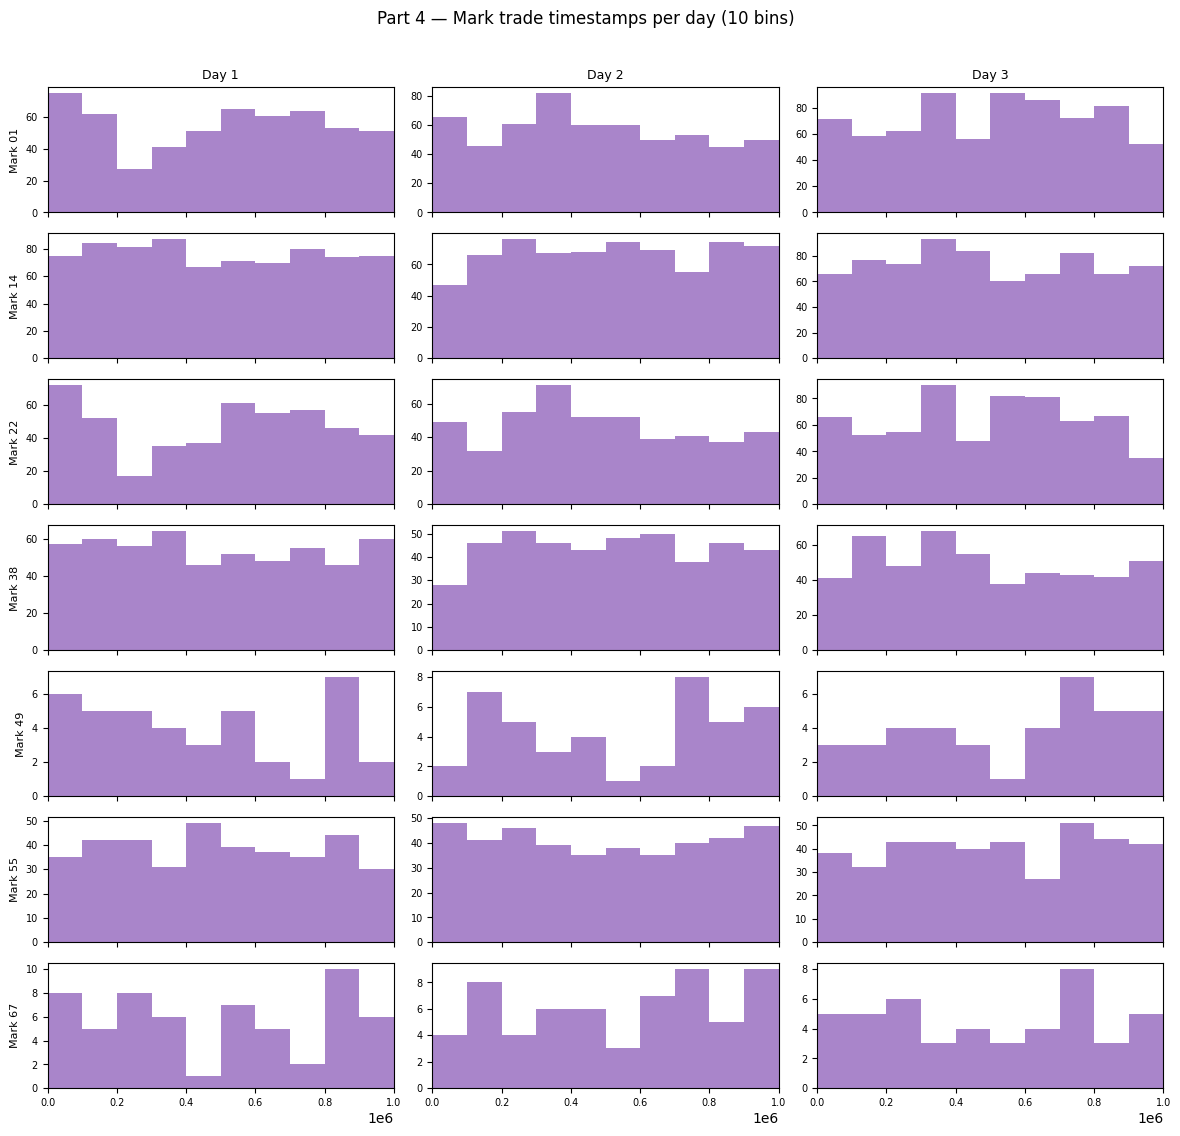


Marks with concentrated activity (max bin > 30% of daily trades):
  none


In [ ]:
# ── Part 4: timing patterns ────────────────────────────────────────────────
sizes = defaultdict(list)
ticks = defaultdict(list)
for tr in trades_r4:
    for who in (tr["buyer"], tr["seller"]):
        if who in COUNTERPARTIES:
            sizes[(who, tr["symbol"])].append(tr["quantity"])
            ticks[(who, tr["symbol"], tr["day"])].append(tr["timestamp"])

print(f"{'Mark':<8} {'Trades':>7} {'Mean':>6} {'Med':>5} {'Max':>5}")
print("-" * 40)
for m in COUNTERPARTIES:
    all_sz = [q for (mm, _), v in sizes.items() if mm == m for q in v]
    if not all_sz: continue
    a = np.asarray(all_sz, dtype=float)
    print(f"{m:<8} {a.size:>7d} {a.mean():>6.2f} {np.median(a):>5.0f} {a.max():>5.0f}")

active_marks = [m for m in COUNTERPARTIES
                if any(len(v) for (mm, _, _), v in ticks.items() if mm == m)]
fig, axes = plt.subplots(len(active_marks), len(DAYS),
                          figsize=(12, 1.6*max(1, len(active_marks))),
                          sharex=True, sharey=False)
if len(active_marks) == 1: axes = np.array([axes])
bins = np.linspace(0, 1_000_000, 11)
for i, m in enumerate(active_marks):
    for j, d in enumerate(DAYS):
        ax = axes[i, j] if axes.ndim == 2 else axes[j]
        all_ts = []
        for sym in ALL_SYMBOLS:
            all_ts.extend(ticks.get((m, sym, d), []))
        if all_ts: ax.hist(all_ts, bins=bins, color="tab:purple", alpha=0.8)
        ax.set_xlim(0, 1_000_000)
        if j == 0: ax.set_ylabel(m, fontsize=8)
        if i == 0: ax.set_title(f"Day {d}", fontsize=9)
        ax.tick_params(labelsize=7)
fig.suptitle("Part 4 — Mark trade timestamps per day (10 bins)", y=1.01)
fig.tight_layout()
fig.savefig("cp_timing.png", dpi=110, bbox_inches="tight")
plt.show()

print("\nMarks with concentrated activity (max bin > 30% of daily trades):")
flagged = []
for m in COUNTERPARTIES:
    for d in DAYS:
        all_ts = [t for sym in ALL_SYMBOLS for t in ticks.get((m, sym, d), [])]
        if len(all_ts) < 20: continue
        counts, _ = np.histogram(all_ts, bins=bins)
        share = counts.max() / counts.sum()
        if share > 0.30:
            print(f"  {m} day {d}: {share*100:.0f}% in one bin (n={counts.sum()})")
            flagged.append((m, d, share))
if not flagged: print("  none")

## Part 5 — Predictive value of Mark trades

For each (Mark, product) with >20 trades, compute the mean log-return at horizons {50, 100, 500, 1000} ticks AFTER each Mark trade, conditioned on direction. Sell-side returns are sign-flipped so positive ⇒ Mark was right. Flag combinations where `|mean| > 2·stderr`.

In [ ]:
# ── Part 5: forward returns ─────────────────────────────────────────────────
horizons = [50, 100, 500, 1000]
pair_count = Counter()
for tr in trades_r4:
    for who in (tr["buyer"], tr["seller"]):
        if who in COUNTERPARTIES:
            pair_count[(who, tr["symbol"])] += 1
active = [(m, s) for (m, s), n in pair_count.items() if n > 20]

buy_means = defaultdict(lambda: np.full(len(horizons), np.nan))
sell_means = defaultdict(lambda: np.full(len(horizons), np.nan))
significant = []

for m, sym in active:
    for direction in ("buy", "sell"):
        forwards = [[] for _ in horizons]
        for tr in trades_r4:
            if tr["symbol"] != sym: continue
            if direction == "buy" and tr["buyer"] != m: continue
            if direction == "sell" and tr["seller"] != m: continue
            arrs = prices_r4[tr["day"]].get(sym)
            if arrs is None: continue
            ts_a, mid_a, _, _ = arrs
            p_now = lookup_at(ts_a, mid_a, tr["timestamp"])
            if np.isnan(p_now) or p_now <= 0: continue
            for hi, h in enumerate(horizons):
                p_fut = lookup_at(ts_a, mid_a, tr["timestamp"] + h*100)
                if np.isnan(p_fut) or p_fut <= 0: continue
                r = np.log(p_fut / p_now)
                if direction == "sell": r = -r
                forwards[hi].append(r)
        means = np.array([np.mean(f) if f else np.nan for f in forwards])
        stes  = np.array([np.std(f, ddof=1)/np.sqrt(len(f)) if len(f)>1 else np.nan for f in forwards])
        if direction == "buy": buy_means[(m, sym)] = means
        else: sell_means[(m, sym)] = means
        for hi, h in enumerate(horizons):
            if not np.isnan(means[hi]) and not np.isnan(stes[hi]) and stes[hi] > 0:
                if abs(means[hi]) > 2*stes[hi]:
                    significant.append((m, sym, direction, h, means[hi], stes[hi]))

print("Statistically meaningful forward returns (|mean| > 2·stderr):")
for m, sym, dr, h, mn, se in significant:
    print(f"  {m:<8} {sym:<22} {dr:<4} h={h:>4}  mean={mn*1e4:>+7.2f}bp  se={se*1e4:>5.2f}bp")
if not significant: print("  none")

Statistically meaningful forward returns (|mean| > 2·stderr):
  Mark 55  VELVETFRUIT_EXTRACT    sell h= 100  mean=  +1.71bp  se= 0.69bp
  Mark 49  VELVETFRUIT_EXTRACT    buy  h= 100  mean=  -5.79bp  se= 2.63bp
  Mark 49  VELVETFRUIT_EXTRACT    sell h=  50  mean=  -3.78bp  se= 1.19bp
  Mark 49  VELVETFRUIT_EXTRACT    sell h= 100  mean=  -3.64bp  se= 1.72bp
  Mark 67  VELVETFRUIT_EXTRACT    buy  h=  50  mean=  +3.65bp  se= 0.93bp
  Mark 67  VELVETFRUIT_EXTRACT    buy  h= 100  mean=  +2.98bp  se= 1.40bp
  Mark 22  VELVETFRUIT_EXTRACT    sell h=  50  mean=  -3.56bp  se= 1.17bp
  Mark 14  VELVETFRUIT_EXTRACT    buy  h= 100  mean=  -2.33bp  se= 0.92bp
  Mark 14  VELVETFRUIT_EXTRACT    sell h=  50  mean=  -1.57bp  se= 0.69bp
  Mark 14  VELVETFRUIT_EXTRACT    sell h= 100  mean=  -2.05bp  se= 0.94bp


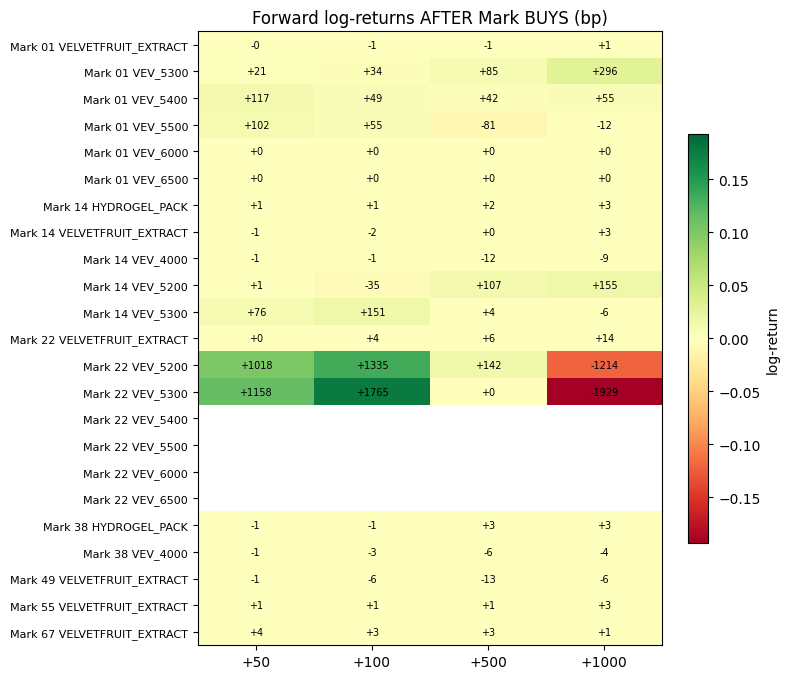

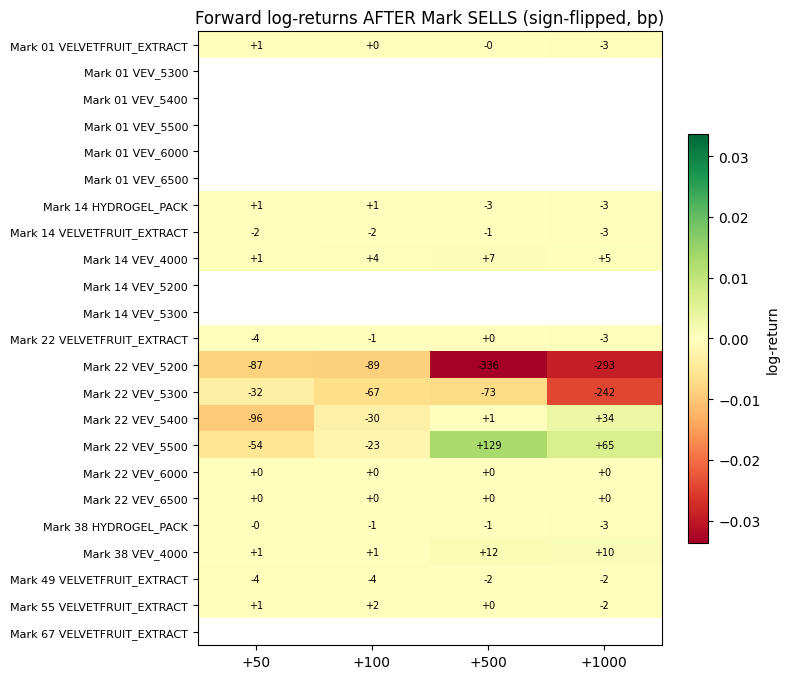

In [ ]:
# ── Part 5: heatmaps ────────────────────────────────────────────────────────
def _heatmap(d, fname, title):
    keys = sorted(d.keys())
    if not keys: return
    labels = [f"{m} {s}" for m, s in keys]
    arr = np.array([d[k] for k in keys])
    finite = arr[np.isfinite(arr)]
    vmax = max(abs(finite.min()), abs(finite.max())) if finite.size else 1e-4
    fig, ax = plt.subplots(figsize=(8, max(2, 0.3*len(keys))))
    im = ax.imshow(arr, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(horizons))); ax.set_xticklabels([f"+{h}" for h in horizons])
    ax.set_yticks(range(len(keys))); ax.set_yticklabels(labels, fontsize=8)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            if np.isfinite(arr[i, j]):
                ax.text(j, i, f"{arr[i, j]*1e4:+.0f}", ha="center", va="center", fontsize=7)
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.04, label="log-return")
    fig.tight_layout(); fig.savefig(fname, dpi=110)
    plt.show()

_heatmap(buy_means, "cp_predictive.png", "Forward log-returns AFTER Mark BUYS (bp)")
_heatmap(sell_means, "cp_predictive_sells.png", "Forward log-returns AFTER Mark SELLS (sign-flipped, bp)")

## Part 6 — Tradability check

The critical test: even if Mark X has positive forward returns, **can WE capture them?** We'd enter at the next-tick best_ask (if buying) or best_bid (if selling), not at Mark's trade price. Compare Mark's per-trade entry edge vs our chase edge at horizons {100, 500, 1000}.

Mark     Symbol                 Dir     N  Mark_edge_bp  Chase_h100bp    h500bp    h1000bp
----------------------------------------------------------------------------------------------------
Mark 01  VEV_5400               buy   263       +574.6       -422.0   -251.5     -73.5
Mark 22  VEV_5400               sell  276       -564.4       -832.7  -1022.1   -1202.7
Mark 01  VEV_5500               buy   299      +1748.6      -1200.0  -1054.1    -905.4
Mark 22  VEV_5500               sell  306      -1734.1      -2343.8  -2463.7   -2729.3
Mark 01  VEV_6000               buy   317     +10000.0      -5000.0  -5000.0   -5000.0
Mark 22  VEV_6000               sell  317     -10000.0         +nan     +nan      +nan
Mark 01  VEV_6500               buy   317     +10000.0      -5000.0  -5000.0   -5000.0
Mark 22  VEV_6500               sell  317     -10000.0         +nan     +nan      +nan
Mark 38  HYDROGEL_PACK          buy   515         -7.9         -8.3     -5.1      -4.6
Mark 38  HYDROGEL_PACK   

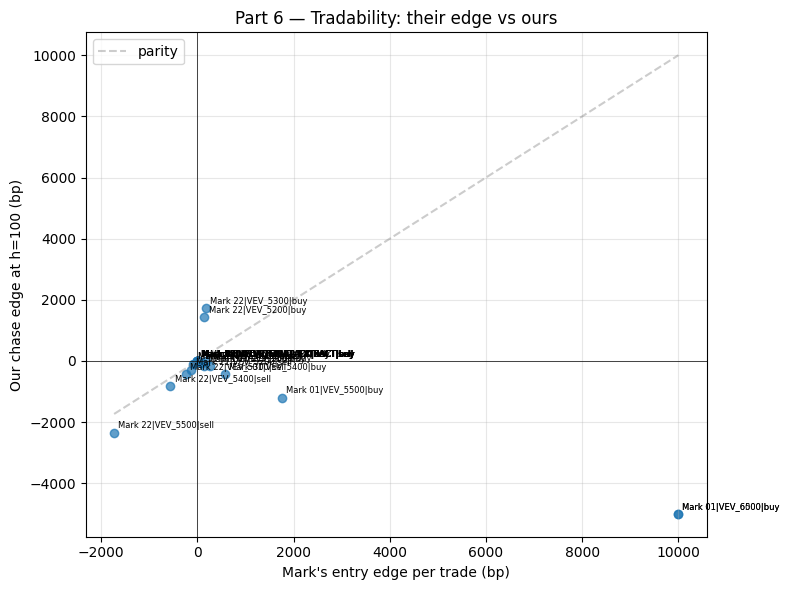

In [ ]:
# ── Part 6: tradability ────────────────────────────────────────────────────
horizons6 = [100, 500, 1000]
rows6 = []
print(f"{'Mark':<8} {'Symbol':<22} {'Dir':<4} {'N':>4}  {'Mark_edge_bp':>12}  "
      f"{'Chase_h100bp':>12}  {'h500bp':>8}  {'h1000bp':>9}")
print("-" * 100)

for (m, sym), n in pair_count.items():
    if n <= 20: continue
    for direction in ("buy", "sell"):
        mark_pnls = []; our_pnls = {h: [] for h in horizons6}
        for tr in trades_r4:
            if tr["symbol"] != sym: continue
            if direction == "buy" and tr["buyer"] != m: continue
            if direction == "sell" and tr["seller"] != m: continue
            arrs = prices_r4[tr["day"]].get(sym)
            if arrs is None: continue
            ts_a, mid_a, bb_a, ba_a = arrs
            p_now = lookup_at(ts_a, mid_a, tr["timestamp"])
            if np.isnan(p_now) or p_now <= 0: continue
            tp = tr["price"]
            mark_edge = (p_now - tp)/p_now if direction == "buy" else (tp - p_now)/p_now
            mark_pnls.append(mark_edge)
            idx = np.searchsorted(ts_a, tr["timestamp"], side="right")
            if idx >= ts_a.size: continue
            entry = ba_a[idx] if direction == "buy" else bb_a[idx]
            if not np.isfinite(entry) or entry <= 0: continue
            for h in horizons6:
                p_fut = lookup_at(ts_a, mid_a, tr["timestamp"] + h*100)
                if np.isnan(p_fut): continue
                pnl = (p_fut - entry)/entry if direction == "buy" else (entry - p_fut)/entry
                our_pnls[h].append(pnl)
        if not mark_pnls: continue
        me = float(np.mean(mark_pnls))
        ours = {h: (float(np.mean(our_pnls[h])) if our_pnls[h] else float("nan")) for h in horizons6}
        rows6.append((f"{m}|{sym}|{direction}", me, ours[100]))
        print(f"{m:<8} {sym:<22} {direction:<4} {len(mark_pnls):>4}  "
              f"{me*1e4:>+11.1f}  {ours[100]*1e4:>+11.1f}  "
              f"{ours[500]*1e4:>+7.1f}  {ours[1000]*1e4:>+8.1f}")

fig, ax = plt.subplots(figsize=(8, 6))
xs = np.array([r[1] for r in rows6])*1e4
ys = np.array([r[2] for r in rows6])*1e4
valid = np.isfinite(xs) & np.isfinite(ys)
ax.scatter(xs[valid], ys[valid], alpha=0.7)
for label, mx, our in rows6:
    if np.isfinite(mx) and np.isfinite(our):
        ax.annotate(label, (mx*1e4, our*1e4), fontsize=6, xytext=(3,3), textcoords="offset points")
ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
if valid.any():
    ax.plot([xs[valid].min(), xs[valid].max()], [xs[valid].min(), xs[valid].max()],
            "--", color="grey", alpha=0.4, label="parity")
ax.set_xlabel("Mark's entry edge per trade (bp)")
ax.set_ylabel("Our chase edge at h=100 (bp)")
ax.set_title("Part 6 — Tradability: their edge vs ours")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("cp_tradability.png", dpi=110)
plt.show()

## Part 7 — Voucher analysis

Per-Mark per-voucher PnL across the 3 days, plus voucher spread distributions. Identify any voucher where a consistent winner trades with >1 partner (the only structurally joinable setup).

In [ ]:
# ── Part 7: voucher PnL grid + spreads ─────────────────────────────────────
grid = np.zeros((len(COUNTERPARTIES), len(VOUCHERS)))
for i, m in enumerate(COUNTERPARTIES):
    for j, v in enumerate(VOUCHERS):
        grid[i, j] = sum(pnl.get((d, m, v), 0.0) for d in DAYS)

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.11; x = np.arange(len(VOUCHERS))
cmap = plt.get_cmap("tab10")
for i, m in enumerate(COUNTERPARTIES):
    ax.bar(x + (i-3)*width, grid[i], width=width, label=m, color=cmap(i % 10))
ax.set_xticks(x); ax.set_xticklabels(VOUCHERS, rotation=30)
ax.set_ylabel("3-day PnL"); ax.set_title("Part 7 — Mark PnL per voucher")
ax.axhline(0, color="black", lw=0.5); ax.legend(ncol=4, fontsize=8); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("vouchers_pnl.png", dpi=110)
plt.show()

# Spread distributions
spreads_by_v = {}
for v in VOUCHERS:
    spreads = []
    for d in DAYS:
        t = prices_r4[d].get(v)
        if t is None: continue
        _, _, bb, ba = t
        s = ba - bb
        spreads.extend(s[np.isfinite(s)].tolist())
    spreads_by_v[v] = np.asarray(spreads, dtype=float)

fig, ax = plt.subplots(figsize=(11, 5))
for j, v in enumerate(VOUCHERS):
    s = spreads_by_v[v]
    if s.size: ax.boxplot(s, positions=[j], widths=0.6, showfliers=False)
ax.set_xticks(range(len(VOUCHERS))); ax.set_xticklabels(VOUCHERS, rotation=30)
ax.set_ylabel("best_ask - best_bid")
ax.set_title("Part 7 — Voucher spread distributions (boxplot, pooled days)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("vouchers_spreads.png", dpi=110)
plt.show()

print("Median spreads per voucher:")
spread_med = {}
for v in VOUCHERS:
    s = spreads_by_v[v]
    spread_med[v] = float(np.median(s)) if s.size else float("nan")
    print(f"  {v}: {spread_med[v]:.2f}")

print("\nVouchers where a consistent winner trades with >1 partner (joinable):")
joinable = []
for v in VOUCHERS:
    for m in winners:
        partners = set()
        for tr in by_sym.get(v, []):
            if tr["buyer"] == m: partners.add(tr["seller"])
            elif tr["seller"] == m: partners.add(tr["buyer"])
        if len(partners) > 1:
            joinable.append((v, m, len(partners)))
            print(f"  {v}: {m} traded with {len(partners)} partners → {sorted(partners)}")
if not joinable: print("  none")

AttributeError: 'numpy.float64' object has no attribute 'get'

## Written Summary

1. **Consistent winners** (positive every day)
2. **Consistent losers**
3. **Tradability** of each winner — accounting for spread cost when chasing
4. **Closed pairs** — Marks that trade only one partner per product
5. **Most promising product × strategy combos**
6. **One-line recommendation**

In [ ]:
# ── Written summary ────────────────────────────────────────────────────────
print(f"1. CONSISTENT WINNERS: {winners or 'none'}")
print(f"2. CONSISTENT LOSERS:  {losers or 'none'}")
print(f"   MIXED:              {mixed}")

print("\n3. Tradability of each consistent winner:")
if not winners:
    print("   N/A")
else:
    for w in winners:
        rel = [r for r in rows6 if r[0].startswith(f"{w}|")]
        if not rel:
            print(f"   - {w}: no >20-trade product"); continue
        their = np.array([r[1] for r in rel])
        ours = np.array([r[2] for r in rel])
        ours = ours[np.isfinite(ours)]
        tag = "POSITIVE" if (ours.size and np.mean(ours) > 0) else "NEGATIVE"
        their_bp = np.mean(their)*1e4
        our_bp = np.mean(ours)*1e4 if ours.size else float('nan')
        print(f"   - {w}: their mean entry edge {their_bp:+.1f}bp; "
              f"chase mean (h=100) {our_bp:+.1f}bp → {tag}")
        for (a, b, sym, n) in closed_pairs:
            if a == w:
                print(f"     [closed pair] on {sym}: {w} ONLY trades {b} ({n}) — cannot join")

print("\n4. CLOSED PAIRS:")
for a, b, sym, n in closed_pairs:
    print(f"   - {a} ↔ {b} on {sym} ({n})")

print("\n5. PRODUCT × STRATEGY combinations supported by the data:")
pos_sig = [s for s in significant if s[4] > 0]
if pos_sig:
    print("   Statistically positive forward returns:")
    for m, sym, dr, h, mn, se in pos_sig:
        print(f"     - {m} {dr} on {sym} h={h}: +{mn*1e4:.1f}bp ± {2*se*1e4:.1f}bp")
    closed_set = {(a, sym) for a, b, sym, n in closed_pairs}
    joinable_combos = [s for s in pos_sig if (s[0], s[1]) not in closed_set]
    if joinable_combos:
        print("   Of those, NOT inside a closed pair:")
        for m, sym, dr, h, mn, se in joinable_combos:
            print(f"     - {m} {dr} on {sym} h={h}: +{mn*1e4:.1f}bp")
    else:
        print("   All positive signals sit inside closed pairs — not joinable.")
else:
    print("   None statistically meaningful.")

# Mark 14 chase on HYDROGEL specifically
h_med = spread_med.get("VEV_4000", float("nan"))
if "Mark 14" in winners:
    h14 = [r for r in rows6 if r[0].startswith("Mark 14|HYDROGEL_PACK")]
    if h14:
        chase = np.array([r[2] for r in h14]); chase = chase[np.isfinite(chase)]
        mc = float(np.mean(chase)) if chase.size else float("nan")
        print(f"\n   HYDROGEL_PACK note: Mark 14 chase edge h=100 = {mc*1e4:+.1f}bp "
              f"→ {'profitable' if mc > 0 else 'NEGATIVE — confirms 800k blow-up'}")

print("\n6. ONE-LINE RECOMMENDATION:")
good_chase = []
for w in winners:
    for r in rows6:
        if r[0].startswith(f"{w}|") and np.isfinite(r[2]) and r[2] > 0:
            good_chase.append((w, r[0], r[2]))
if good_chase:
    best = max(good_chase, key=lambda x: x[2])
    print(f"   Following {best[0]} via best-ask chase is positive ONLY for {best[1]} "
          f"({best[2]*1e4:+.1f}bp at h=100) — focus narrowly there; do NOT chase HYDROGEL.")
elif winners:
    print("   Mark 14 is a clear winner but their edge is consumed by spread when chased; "
          "do NOT trade off Mark signals on HYDROGEL — instead use buyer/seller fields "
          "as a defensive flag (avoid trading against Mark 14, avoid trading with Mark 38).")
else:
    print("   No counterparty produces a stable joinable signal — leave the trader as-is.")

## R4 Rolling Mean and Std — HYDROGEL_PACK & VELVETFRUIT_EXTRACT

Load round 4 days 1→3, stitch into a continuous timeline, then plot the mid price overlaid with the rolling mean (window=1000, matching `BOLL_WINDOW`) and the rolling std on a second axis. Also print the per-day and pooled overall mean/std as scalars.

Product                Day         Mean        Std
--------------------------------------------------
HYDROGEL_PACK          1        9992.06    37.6130
HYDROGEL_PACK          2        9989.40    31.6222
HYDROGEL_PACK          3       10002.50    32.9529
HYDROGEL_PACK          all      9994.65    34.6233
VELVETFRUIT_EXTRACT    1        5248.39    14.6144
VELVETFRUIT_EXTRACT    2        5255.39    16.9853
VELVETFRUIT_EXTRACT    3        5239.16    18.5952
VELVETFRUIT_EXTRACT    all      5247.65    18.0771


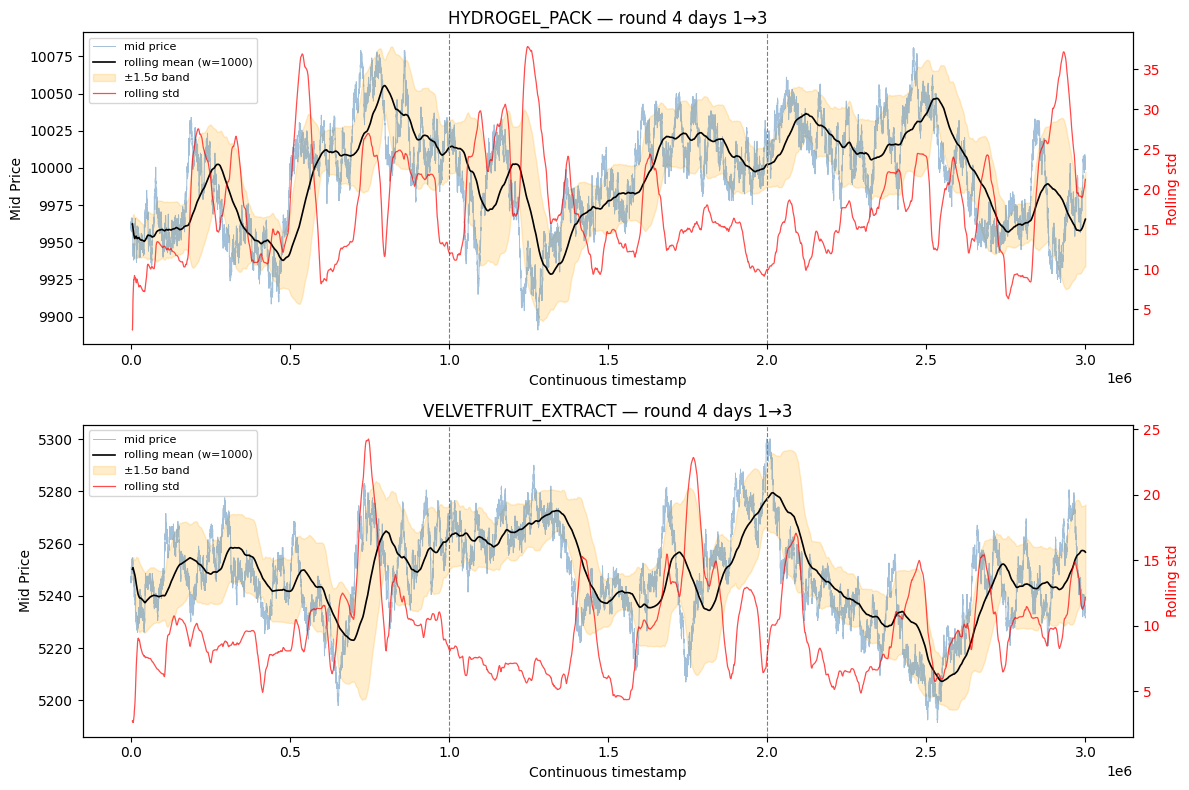

In [306]:
# Rolling mean & std for HYDROGEL_PACK and VELVETFRUIT_EXTRACT (round 4)
import pandas as pd
import matplotlib.pyplot as plt

DAY_LENGTH = 1_000_000
ROLL_WINDOW = 1000  # matches BOLL_WINDOW in submission_round3.py

# Load round 4 prices
r4_dfs = {}
for day in [1, 2, 3]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round4/prices_round_4_day_{day}.csv',
        sep=';'
    )
    r4_dfs[day] = df[df['mid_price'] > 0]

products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

# Print scalar mean / std per (product, day) and pooled
print(f"{'Product':<22} {'Day':<5} {'Mean':>10} {'Std':>10}")
print("-" * 50)
pooled = {p: [] for p in products}
for product in products:
    for day, df in r4_dfs.items():
        s = df.loc[df['product'] == product, 'mid_price']
        print(f"{product:<22} {day:<5} {s.mean():>10.2f} {s.std():>10.4f}")
        pooled[product].append(s)
    all_s = pd.concat(pooled[product])
    print(f"{product:<22} {'all':<5} {all_s.mean():>10.2f} {all_s.std():>10.4f}")

# Stitched plot: price + rolling mean + rolling std (twin axis)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, product in zip(axes, products):
    frames = []
    for day, df in r4_dfs.items():
        chunk = df[df['product'] == product].copy()
        chunk['cont_ts'] = chunk['timestamp'] + (day - 1) * DAY_LENGTH
        frames.append(chunk)
    combined = pd.concat(frames).sort_values('cont_ts').reset_index(drop=True)

    roll = combined['mid_price'].rolling(ROLL_WINDOW, min_periods=50)
    rolling_mean = roll.mean()
    rolling_std = roll.std()

    ax.plot(combined['cont_ts'], combined['mid_price'],
            color='steelblue', alpha=0.5, linewidth=0.7, label='mid price')
    ax.plot(combined['cont_ts'], rolling_mean,
            color='black', linewidth=1.2, label=f'rolling mean (w={ROLL_WINDOW})')
    ax.fill_between(combined['cont_ts'],
                    rolling_mean - 1.5 * rolling_std,
                    rolling_mean + 1.5 * rolling_std,
                    color='orange', alpha=0.2, label='±1.5σ band')
    ax.set_title(f'{product} — round 4 days 1→3')
    ax.set_xlabel('Continuous timestamp')
    ax.set_ylabel('Mid Price')
    ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)

    # Twin axis for rolling std
    ax2 = ax.twinx()
    ax2.plot(combined['cont_ts'], rolling_std,
             color='red', linewidth=0.9, alpha=0.7, label='rolling std')
    ax2.set_ylabel('Rolling std', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()
